# CDR: Gas Generator Design

> Author: Elias Aoubala

> Date: 21/04/2025

In [2]:
import numpy as np
import handcalcs.render
import pandas as pd
import matplotlib.pyplot as plt
import CoolProp.CoolProp as CP
from scipy.interpolate import interpn
from rocketcea.cea_obj_w_units import CEA_Obj
from turborocket.transient.start_up import GasGenerator
from turborocket.combustion.comb_solver import CombustionCantera
from turborocket.fluids.fluids import IncompressibleFluid
import matplotlib.pyplot as plt

import pprint

## 1 - Background

This document encapsulates the analysis conducted on the design of the gas-generator of the "Mermaidman and Barnacle Boy" turbopump, as part of the R2S 2025 competition.

This document describes the high level fluidic and mechanical design performed on the gas-generator used to drive the turbine for the turbopump.

## 2 - High Level Specification

The following high-level specifications have been used for the gas-generator operation, which is as follows:

| Parameter                 | Value       | Justification                                                         |
| ------------------------- | ----------- | --------------------------------------------------------------------- |
| Propellants               | N2O/IPA     | High Level Specification of the Mermaidman and Barnacle Boy Turbopump |
| Ignition System           | H2/O2 Torch | High Level Specification of the Mermaidman and Barnacle Boy Turbopump |
| Nitrous Delivery Pressure | 50 Bar      | Assumed Delivery Pressure from R2S Test-site (Protolaunch)            |
| IPA Delivery Pressure     | 50 Bar      | Target Exit Pressure of the Fuel Pump                                 |

## 3 - Mixture Ratio Sensitivity Study and Specification

A brief sensitivity study was performed to investigate how different O/F ratios would influence gas generator exhaust parameters.

The python library `rocketcea` was used to generate all fluidic parameters over a large range of mixture ratios.

In this study, a focus has been made primarily on fuel rich mixture ratios.

#### 3.1.5 - Conclusion

For the gas-generator, we fundementally desire a high specific gas constant (implying low gas density) and thus workable areas, high specific heat capacity (implying higher enthalpy) and low specific gas constant (implying shock losses are lower), hence we can oprt for an O/F of **0.75 at 30 Bar**.

### 3.2 - Start-up Ignitability

It is of uptmost importance that we ensure that the gas-generator is capable of igniting at startup, where the nitrous pressure delivery will be high, while the IPA pressure is low as the pump begins to spin-up.

This section of the analysis investigated this phenomena to see if ignitability is possible at initial low pressure IPA igntion.

The key criteria for driving ignitability here will be mixing (indirectly computed via injector stifness), along with resultant MR at ignition.

Based on discussions with the pump designer Craig, the following inlet pressure is expected for the design:

| Parameter                 | Value  | Justification                               |
| ------------------------- | ------ | ------------------------------------------- |
| Start-up IPA Pressure     | 20 Bar | Specific Inlet Pressure of the IPA pump     |
| Start-up Nitrous Pressrue | 50 Bar | Test-site delivery pressure for the Nitrous |

Simple Injection Modelling has been used for thes two fluids, with no "two-phase" flow assumptions being applied for the Nitrous line.

#### 3.2.1 - Injector Modelling

The simple equation for incompressible flow through a infinitesimly thin orfice has been used.

It has been assumed that the discharge coefficient remains constant and is indepenedent of pressure drop.


$$\dot{m} = C_d A \sqrt{2 \rho (P_1 - P_2)}$$

Where $P_1$ refers to the delivery pressure, $P_2$ refers to the combustion chamber pressure, $\rho$ refers to the propellant density and $C_d A$ referse to the orifice effective area.

We can divide this mass-flow rate by the throat area of the chamber, and encapsule the constant elements of the equation into a single parameter.

$$\frac{\dot{m}}{A_c} = \frac{C_d A \sqrt{2 \rho}}{A_c} \sqrt{P_1 - P_c} = K \sqrt{P_1 - P_c}$$

Now if we were to compare the ox and fuel sides, we can derive these parameters based on one another as we already know the target mixture ratio of the system:

$$MR = \frac{\dot{m}_{ox}}{\dot{m}_f} = \frac{\dot{m}_{ox}}{A_c} \frac{A_c}{\dot{m}_{f}} = \frac{K_{ox} \sqrt{P_{ox} - P_c}}{K_{f} \sqrt{P_f - P_c}}$$

As we already know the pressure drops of the system under the target case, we can thus derive the relationship between these two parameters accordingly by re-arranging in the following manner:

$$K_{ox} \sqrt{P_{ox} - P_c} = K_{f} \sqrt{P_f - P_c} MR $$

$$K_{ox} = K_{f} \frac{\sqrt{P_f - P_c} MR}{\sqrt{P_{ox} - P_c} } $$

$$K_{ox} = \alpha K_{f}$$

#### 3.2.2 - Chamber Modelling

A simple isentropic choked flow assumption will be used for the chamber modelling at this stage.

$$\dot{m} = \frac{A P_c}{\sqrt{T_o}} \sqrt{\frac{\gamma}{R}} \left( \frac{\gamma + 1}{2} \right)^{-\frac{\gamma + 1}{2 ( \gamma -1 )}}$$

We can re-arrange this by dividing by the throat area, to get the following relationship:

$$\frac{\dot{m}}{A_c} = \frac{P_c}{\sqrt{T_o}} \sqrt{\frac{\gamma}{R}} \left( \frac{\gamma + 1}{2} \right)^{-\frac{\gamma + 1}{2 ( \gamma -1 )}}$$

We can go on to equate the left hand side to the sum of the orifice flows from both the oxidiser and fuel to get the following:

$$K_{ox} \sqrt{P_{ox} - P_c} + K_{f} \sqrt{P_{f} - P_c}= \frac{P_c}{\sqrt{T_o}} \sqrt{\frac{\gamma}{R}} \left( \frac{\gamma + 1}{2} \right)^{-\frac{\gamma + 1}{2 ( \gamma -1 )}}$$

We can employ that factor relationship we defined previously between the two orifices, to thus get the following:

$$K_{f} \left( \alpha\sqrt{P_{ox} - P_c} + \sqrt{P_{f} - P_c} \right)= \frac{P_c}{\sqrt{T_o}} \sqrt{\frac{\gamma}{R}} \left( \frac{\gamma + 1}{2} \right)^{-\frac{\gamma + 1}{2 ( \gamma -1 )}}$$

From here, we can set our target pressure for delivery (P_ox and P_f, and directly solve for the chamber pressure) and conditions.

We can back calculate the mixture ratios by doing the following:

$$MR = \alpha \frac{\sqrt{P_{ox} - P_c}}{\sqrt{P_f - P_c}}$$


This can be done for a range of K_f values to give us an idea of how gas-generator mass-flow influences the start-up O/F of the engine, where K_f is equal to the following:

$$K_f = \frac{(C_d A)_f \sqrt{2 \rho_f}}{A_c} $$

There is three key variables which influence this variation in set-point, namely the nominal chamber pressure ($P_c$), the target MR (influences $\alpha$) and engine size ($K_f$).

A case study has been performed for a theoretical 500 N gg to evaluate how this drift would occur.


#### 3.2.3 - Parameteric Study

Defining our key parameters for the engine

**Chamber Parameter**

In [63]:
%%render param sci_not

Pcc = 25e5 # Pa
MR_nom = 1
eta_c = 0.85
m_dot_t = 111.954e-3 # kg/s


<IPython.core.display.Latex object>

**Injector Parameters**

Fuel Side:

In [64]:
%%render param sci_not

Pf_inlet = 50e5 # Pa
rho_f_inlet = 786 # kg/s
Cd_f = 0.25

<IPython.core.display.Latex object>

Oxidiser Side:

In [65]:
%%render param sci_not

Po_inlet = 50e5 # Pa
rho_o_inlet = CP.PropsSI("D", "P", Po_inlet, "Q", 0, "NitrousOxide") # kg/s
Cd_o = 0.3

<IPython.core.display.Latex object>

We then define our classes for the gas generator

In [66]:
Nitrous = IncompressibleFluid(
    rho=rho_o_inlet, P=Po_inlet
)
IPA = IncompressibleFluid(rho=rho_f_inlet, P=Pf_inlet)

GG = GasGenerator(
    Ox="N2O", Fu="C3H8O,2propanol", Pcc=Pcc, MR=MR_nom
)  # , look_up_file="combustion_date.csv"

GG.comb_object(
    look_up=True, combustion_file="n2o_ipa.yaml", look_up_file="combustion_date.csv"
)

In [67]:
GG.injector_cond(ox_in=Nitrous, fu_in=IPA, cdo=Cd_o, cdf=Cd_f)

GG.size_system(m_dot=m_dot_t, eta_c=eta_c)

{'P_cc': 2500000.0,
 'MR': np.float64(1.0),
 'T_o': array([868.17100688]),
 'Cp': array([2242.55942398]),
 'gamma': array([1.29031402]),
 'R': array([504.56433872]),
 'ox_stiffness': 1.0,
 'fu_stiffness': 1.0,
 'm_dot_t': array([0.111954]),
 'm_dot_o': array([0.055977]),
 'm_dot_f': array([0.055977])}

In [68]:
GG.get_geometry()

{'CdA_ox': np.float64(8.914471692165567e-07),
 'CdA_fu': np.float64(8.929216317561218e-07),
 'A_fu': np.float64(3.5716865270244873e-06),
 'A_ox': np.float64(2.971490564055189e-06),
 'Acc': array([4.45357383e-05])}

We can now sweep through a range of inlet pressures on the fuel side and see how differing the injector stiffness, combustion temperatures and the mixture ratios vary

In [69]:
P_inlet_array = np.linspace(25, 70, 100)*1e5

P_cc_array = []
MR_array = []
T_o_array = []
cp_array = []
gamma_array = []
ox_stiff_array = []
fu_stiff_array = []
m_dot_t_array = []
m_dot_ox_array = []
m_dot_fu_array = []
error_array = []

for p in P_inlet_array:

    fuel = IncompressibleFluid(rho=rho_f_inlet, P=p)

    dic = GG.solve_perturb_ss(fu_in=fuel, ox_in=Nitrous)

    P_cc_array.append(dic["P_cc"])
    MR_array.append(dic["MR"])
    T_o_array.append(dic["T_o"])
    cp_array.append(dic["Cp"])
    gamma_array.append(dic["gamma"])
    ox_stiff_array.append(dic["ox_stiffness"])
    fu_stiff_array.append(dic["fu_stiffness"])
    m_dot_t_array.append(dic["m_dot_t"])
    m_dot_ox_array.append(dic["m_dot_o"])
    m_dot_fu_array.append(dic["m_dot_f"])
    error_array.append(dic["error"])

Text(0.5, 0, 'Fuel Inlet Pressure (Bar)')

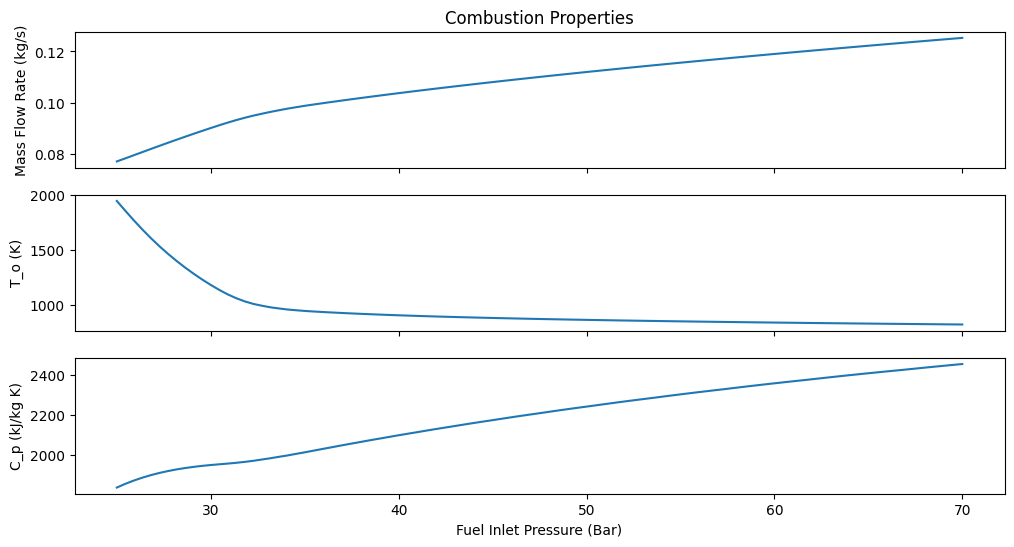

In [70]:
fig, ax = plt.subplots(3, 1, sharex=True)

fig.set_size_inches(12, 6)

# First Plot will be Mass Flow
ax[0].plot(P_inlet_array / 1e5, m_dot_t_array)
ax[0].set_ylabel("Mass Flow Rate (kg/s)")
ax[0].set_title("Combustion Properties")


# Second Plot will be Stagnation Temperature
ax[1].plot(P_inlet_array / 1e5, T_o_array)
ax[1].set_ylabel("T_o (K)")


# Thrid Plot will be Specific Heat Capacity
ax[2].plot(P_inlet_array / 1e5, cp_array)
ax[2].set_ylabel("C_p (kJ/kg K)")
ax[2].set_xlabel("Fuel Inlet Pressure (Bar)")

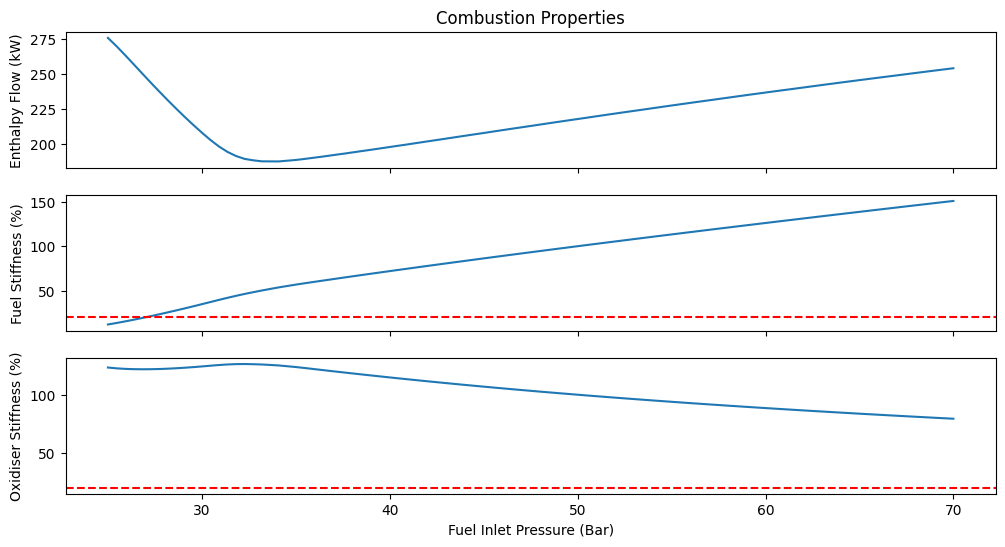

In [71]:
fig, ax = plt.subplots(3,1, sharex=True)

fig.set_size_inches(12, 6)

# First Plot will be the Total Enthalpy Delivered
enthalpy_flow = np.array(m_dot_t_array) * np.array(cp_array) * np.array(T_o_array)
ax[0].plot(P_inlet_array/1e5, enthalpy_flow/1e3)
ax[0].set_ylabel("Enthalpy Flow (kW)")
ax[0].set_title("Combustion Properties")


# Second Plot will be Fuel Stiffness
ax[1].plot(P_inlet_array/1e5, np.array(fu_stiff_array)*100)
ax[1].set_ylabel("Fuel Stiffness (%)")
ax[1].axhline(20, linestyle="--", color="r")


# Thrid Plot will be Oxidiser Stiffness
ax[2].plot(P_inlet_array/1e5, np.array(ox_stiff_array)*100)
ax[2].set_ylabel("Oxidiser Stiffness (%)")
ax[2].set_xlabel("Fuel Inlet Pressure (Bar)")
ax[2].axhline(20, linestyle="--", color="r")

Text(0.5, 0, 'Fuel Inlet Pressure (Bar)')

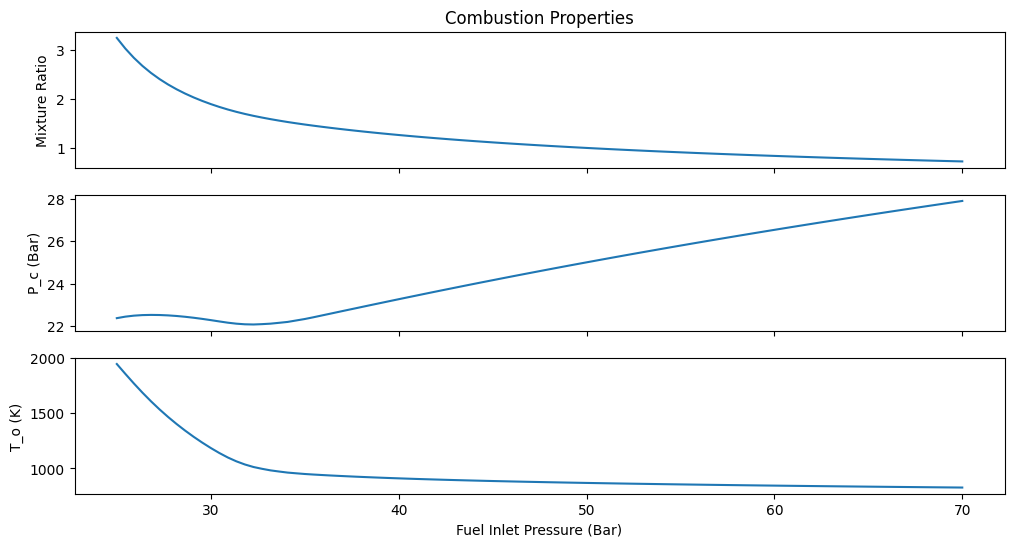

In [73]:
fig, ax = plt.subplots(3, 1, sharex=True)

fig.set_size_inches(12, 6)

# First Plot will be Mixture Ratio
ax[0].plot(P_inlet_array / 1e5, MR_array)
ax[0].set_ylabel("Mixture Ratio")
ax[0].set_title("Combustion Properties")


# Second Plot will be Chamber Pressure
ax[1].plot(P_inlet_array / 1e5, np.array(P_cc_array) / 1e5)
ax[1].set_ylabel("P_c (Bar)")


# Thrid Plot will be Stagnation Temperature
ax[2].plot(P_inlet_array / 1e5, T_o_array)
ax[2].set_ylabel("T_o (K)")
ax[2].set_xlabel("Fuel Inlet Pressure (Bar)")

Text(0.5, 0, 'Fuel Inlet Pressure (Bar)')

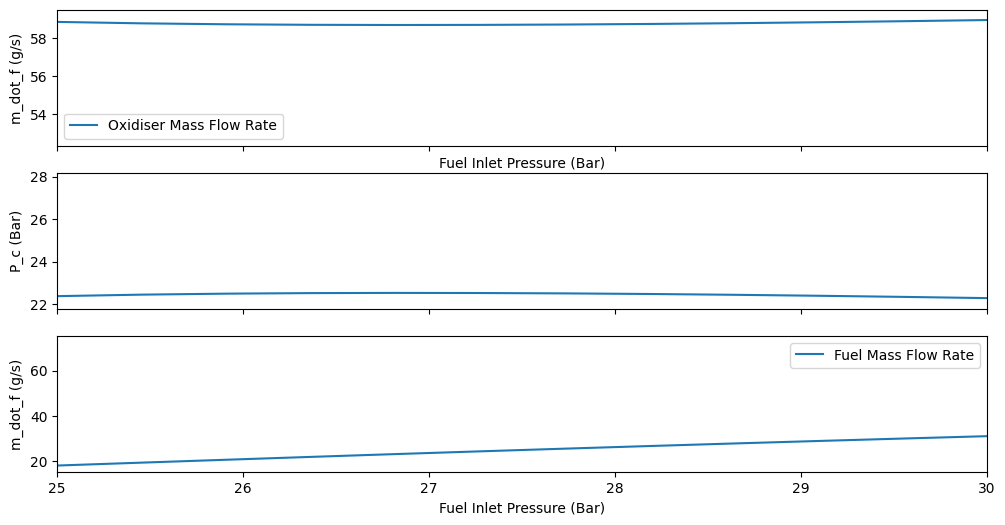

In [85]:
fig, ax = plt.subplots(3, 1, sharex=True)

fig.set_size_inches(12, 6)

# First Plot will be Mixture Ratio
ax[0].plot(P_inlet_array / 1e5, np.array(m_dot_ox_array)*1e3, label="Oxidiser Mass Flow Rate")
ax[0].legend()
ax[0].set_xlim([25, 30])
ax[0].set_ylabel("m_dot_f (g/s)")
ax[0].set_xlabel("Fuel Inlet Pressure (Bar)")


# Second Plot will be Chamber Pressure
ax[1].plot(P_inlet_array / 1e5, np.array(P_cc_array) / 1e5)
ax[1].set_ylabel("P_c (Bar)")


# Thrid Plot will be Flow Rates
ax[2].plot(P_inlet_array / 1e5, np.array(m_dot_fu_array)*1e3, label = "Fuel Mass Flow Rate")
ax[2].legend()
ax[2].set_xlim([25,30])
ax[2].set_ylabel("m_dot_f (g/s)")
ax[2].set_xlabel("Fuel Inlet Pressure (Bar)")

## 4 - Conclusion and Baseline

Based on the sensitivity studies conducted, a MR of 1 has been selected as the baseline for the gas generator.

The following key parameters for the combustion performance to feed the turbine design have been derived.

In [25]:
Nitrous.set_pressure(P=Pf_inlet)
IPA.set_pressure(P=50e5)

GG.injector_cond(ox_in=Nitrous, fu_in=IPA, cdo=Cd_o, cdf=Cd_f)

array = GG.size_system(m_dot=111.954e-3, eta_c=eta_c)

pprint.pprint(array)

{'Cp': array([2242.55942398]),
 'MR': np.float64(1.0),
 'P_cc': 2500000.0,
 'R': array([504.56433872]),
 'T_o': array([868.17100688]),
 'fu_stiffness': 1.0,
 'gamma': array([1.29031402]),
 'm_dot_f': array([0.055977]),
 'm_dot_o': array([0.055977]),
 'm_dot_t': array([0.111954]),
 'ox_stiffness': 1.0}


In [33]:
geom = GG.get_geometry()

pprint.pprint(geom)

{'A_fu': np.float64(3.5716865270244873e-06),
 'A_ox': np.float64(2.971490564055189e-06),
 'Acc': array([4.45357383e-05]),
 'CdA_fu': np.float64(8.929216317561218e-07),
 'CdA_ox': np.float64(8.914471692165567e-07)}


In [36]:
fuel = IncompressibleFluid(rho=rho_f_inlet, P=40e5)

dic = GG.solve_perturb_ss(fu_in=fuel, ox_in=Nitrous)

print(dic["T_o"] - 273.15)

[636.64129657]


## 5 - Injector Geometry Design

Given the finalised design point for the engine, we will now look at sizing of the gas generator injector geometries

For our intial estimate, lets assume three coaxial elements.

In [27]:
%%render sci_not

N = 3

A_ox = geom["A_ox"]/N # m**2

A_fu = geom["A_fu"]/N # m**2

<IPython.core.display.Latex object>

We will design around a central IPA element, with the ox element being in the outer radius.

This helps, as the two major uknowns here are:

- Estimation of Nitrous Cd's when undergoing long flow contractions and flashing in the needle.
- GG Ignitability.

Both can be derisked by assuming IPA central element, as if the IPA Cd is less than expected, O/F will be higher.

In [28]:
%%render sci_not

D_ipa_core = (A_fu/(np.pi))**(1/2) * 2 # m

<IPython.core.display.Latex object>

As computed the inner diameter is almost 1.2 mm, so we can use this tubing which has an inner diameter of approximately 1.09 mm.

Tubing: https://www.adhesivedispensing.co.uk/stainless-steel-16g-tube-165mm-od-sst16-4108-p.asp



To evaluate the impact this will have on our stiffness, lets evaluate what the area ration between these two are

In [29]:
%%render

A_id_tube = np.pi * (1.2e-3/2)**2

A_rat = A_id_tube/A_fu

<IPython.core.display.Latex object>

To get an idea of the impact this will have on flow rate, we need to identify how this area ratio will influence the pressure drop ratio across the injector.

For this, we will assume a constant discharge coefficient.

In [30]:
%%render

dp_rat = (1/A_rat)**2

<IPython.core.display.Latex object>

This means all things considered, with this tube the pressure drop will be 60% lower than the current baseline.

Let's evaluate for this case at the starting condition:

In [31]:
fuel = IncompressibleFluid(rho=rho_f_inlet, P=25e5)

dic = GG.solve_perturb_ss(fu_in=fuel, ox_in=Nitrous)

P_cc = dic["P_cc"]
p_drop = (25e5 - dic["P_cc"])

print(f"Combustion Chamber Pressure: {P_cc/1e5} Bar")
print(f"Nominal Pressure Drop: {p_drop/1e5} Bar")
print(f"Current Injector: {p_drop*dp_rat/1e5} Bar")

Combustion Chamber Pressure: [22.37790959] Bar
Nominal Pressure Drop: [2.62209041] Bar
Current Injector: [2.90567527] Bar


This is marginal variation, and thus this was considered acceptable.

We can now solve for the area of the outer anulus by consdering the wall thicknes of the tube at `1.65 mm`

In [32]:
%%render sci_not

r_outer = ((np.pi*(1.65e-3/2)**2 + A_ox)/np.pi)**(1/2) * 2

<IPython.core.display.Latex object>

This is approximately 2 mm, which we can use accordingly.

For the siver solder fit, we will aim for 0.1-0.3 mm spacing for the holes, thus we will target 1.85 +/- 0.2 mm holes.

As these are small holes, we have an L/D limit of 4 on these components,

This results in a maximum wall thickness for the upper housing plate of 7 mm. We will baseline 5 mm.

For the outter housing, we will specify standard tolerance for the whole of +/- 0.1 mm, with the additional specification that the whole depth must be less than 8 mm.

### 5.1 - Baseline Injector Geometery

The baseline injector geometry is as follows:

| Parameter             | Value   | Tolerance   |
| --------------------- | ------- | ----------- |
| Tube ID               | 1.2mm   | -           |
| Tube OD               | 1.6mm   | -           |
| Annulus OD            | 2 mm    | +/- 0.05 mm |
| Max t_anulus          | 7 mm    | +/- 0.1 mm  |
| Tube Socket Solder OD | 2.00 mm | +/- 0.1 mm |
| Max t_socket          | 5 mm    | +/- 0.1 mm  |

### 5.2 - Static Pressure Evaluation

For the static pressure evalation of the system, we need to know the injection velocity

In [1]:
%%render

rho_inj = 787

A_inj = np.pi * (1.2e-3 /2 )**2

v_inj = 111.954e-3/(rho_ipa

UsageError: Cell magic `%%render` not found.


## 6 - Gas Generator Trim Burns

This section contains the inputs for the trim brun parameters, and allows for quick calculations for the pumps

### 6.1 - Constraints

The Following constraints apply

#### 5.1.1 - IPA

Target Inlet: [25 Bar]

Minimum Inlet: 5 Bar

Maximum Inlet: 70 Bar

#### 5.1.2 - N2O

Target: [50 Bar]

Maximum Upper: Whatever lol - Fintan

### 6.2 - Orifice Calculator

Here we have the orifice calculator for the turbopump

#### 6.2.1 - IPA Calculator

Target:

In [33]:
%%render sci_not params

Cda_target = 8.929e-7 # m**2

rho_ipa = 787

<IPython.core.display.Latex object>

Inputs

In [ ]:
%%render params sci_not

P_GG_IPA = 20.04e5 # Bar

P_GG_CH = 3e5 # Bar

m_dot = 114e-3 # kg/s



<IPython.core.display.Latex object>

Calculation

In [93]:
%%render sci_not

dp = P_GG_IPA - P_GG_CH

cda_actual = m_dot/(2 * rho_ipa * dp)**(1/2)

deviation = (cda_actual - cda_target)/cda_target * 100 

<IPython.core.display.Latex object>

Pressure Adjustment

In [ ]:
%%render

a_actual = 

In [89]:
%%render sci_not

dp_new = dp * (cda_actual/cda_target)**2 /1e5 # Bar

<IPython.core.display.Latex object>

#### 6.2.2 - N20 Calculator

Target:

In [62]:
%%render sci_not params

Cda_target = 8.9144726e-7 # m**2

dp_target = 25e5

rho_n2o = 788

<IPython.core.display.Latex object>

Inputs

In [43]:
%%render params sci_not

P_GG_IPA = 50e5 # Bar

P_GG_CH = 25e5 # Bar

m_dot = 55e-3 # kg/s



<IPython.core.display.Latex object>

Calculation

In [44]:
%%render 

dp = P_GG_IPA - P_GG_CH

cda_actual = m_dot/(2 * rho_ipa * dp)**(1/2)

deviation = (cda_actual - cda_target)/cda_target * 100 

<IPython.core.display.Latex object>

Pressure Adjustment

In [46]:
%%render sci_not

dp_new = dp * (cda_actual/cda_target)**2 /1e5 # Bar

<IPython.core.display.Latex object>

#### 6.2.3 - Propellant Scaling

Final Propellant Scaling

**Target**

In [52]:
%%render

p_rat_ign = 25 - 20

p_rat_nom = 50 - 25

m_rat = (p_rat_nom/p_rat_ign)**(1/2)

<IPython.core.display.Latex object>

**Actual**

Input

In [56]:
%%render params sci_not

dp_a = 5e5

<IPython.core.display.Latex object>

Output

In [60]:
%%render params

dp_2 = dp_a*(m_rat**2)/1e5

<IPython.core.display.Latex object>